In [1]:
!unzip ft_XLM_RoBERTa_Large.zip

Archive:  ft_XLM_RoBERTa_Large.zip
   creating: ft_XLM_RoBERTa_Large/
  inflating: ft_XLM_RoBERTa_Large/bert_fine_tuning_peft.py  
   creating: ft_XLM_RoBERTa_Large/best_params/
   creating: ft_XLM_RoBERTa_Large/best_params/.ipynb_checkpoints/
  inflating: ft_XLM_RoBERTa_Large/best_params/.ipynb_checkpoints/get_best_params-checkpoint.ipynb  
  inflating: ft_XLM_RoBERTa_Large/best_params/best_params.xlsx  
  inflating: ft_XLM_RoBERTa_Large/best_params/get_best_params_augmented_bnf16.ipynb  
  inflating: ft_XLM_RoBERTa_Large/best_params/p-xlm-r-large.json  
   creating: ft_XLM_RoBERTa_Large/best_params/runs/
   creating: ft_XLM_RoBERTa_Large/best_params/runs/Jul11_08-57-06_5b463299fe49/
  inflating: ft_XLM_RoBERTa_Large/best_params/runs/Jul11_08-57-06_5b463299fe49/events.out.tfevents.1783760229.5b463299fe49.4574.0  
   creating: ft_XLM_RoBERTa_Large/best_params/runs/Jul11_09-05-22_5b463299fe49/
  inflating: ft_XLM_RoBERTa_Large/best_params/runs/Jul11_09-05-22_5b463299fe49/events.out.tfev

In [2]:
%cd ft_XLM_RoBERTa_Large

/content/ft_XLM_RoBERTa_Large


In [3]:
!pip install -r requirements.txt

  Cloning https://github.com/huggingface/peft (to revision cf04d0353f0343cbf66627228c4495f51669af34) to /tmp/pip-install-nzelj212/peft_98e6ad5c10f94766898804f09f48c1dc
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/peft /tmp/pip-install-nzelj212/peft_98e6ad5c10f94766898804f09f48c1dc
  Running command git rev-parse -q --verify 'sha^cf04d0353f0343cbf66627228c4495f51669af34'
  Running command git fetch -q https://github.com/huggingface/peft cf04d0353f0343cbf66627228c4495f51669af34
  Running command git checkout -q cf04d0353f0343cbf66627228c4495f51669af34
  Resolved https://github.com/huggingface/peft to commit cf04d0353f0343cbf66627228c4495f51669af34
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.5

In [4]:
import pandas as pd
import numpy as np
import os
import torch
import time
import json

from peft import LoraConfig, LoraModel, get_peft_model, TaskType
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)

os.environ["TOKENIZERS_PARALLELISM"] = "false"
use_cuda = torch.cuda.is_available()

In [5]:
df = pd.read_csv('dataset/all_data.csv')
train_data = pd.read_csv('dataset/train_augmented.csv')
train_data['label'] = train_data['label'].str.capitalize()
val_data = pd.read_csv('dataset/val.csv')
test_data = pd.read_csv('dataset/test.csv')

# Length train, val, and test
print("Train: ",len(train_data))
print("Val: ",len(val_data))
print("Test: ",len(test_data))

Train:  8472
Val:  1062
Test:  1062


In [6]:
tags = np.unique(df['label'])
num_labels = len(tags)
max_length = 128
label2id = {t: i for i, t in enumerate(tags)}
id2label = {i: t for i, t in enumerate(tags)}

In [7]:
def model_init(model_name):
    global tokenizer
    global data_collator
    global tr_model

    base_model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id
    )
    tokenizer = AutoTokenizer.from_pretrained(model_name, model_max_length=128)

    # Configure LoRA
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=8, # Rank of the low-rank matrices
        lora_alpha=32,
        lora_dropout=0.1
    )

    # Wrap the base model with the LoRA configuration
    model = get_peft_model(base_model, lora_config)
    model.print_trainable_parameters()

    return model, tokenizer


def tokenize_function(examples):
    # process the input sequence
    tokenized_input = tokenizer(examples["tweet"],
                                truncation=True,
                                padding='max_length',
                                max_length=max_length)
    # process the labels
    tokenized_input['label'] = [label2id[lb] for lb in examples['label']]

    return tokenized_input


def preprocessing():
    X_train = Dataset.from_pandas(train_data)
    X_val = Dataset.from_pandas(val_data)
    X_test = Dataset.from_pandas(test_data)

    tokenized_train_data = X_train.map(tokenize_function, batched=True)
    tokenized_val_data = X_val.map(tokenize_function, batched=True)
    tokenized_test_data = X_test.map(tokenize_function, batched=True)

    return tokenized_train_data, tokenized_val_data, tokenized_test_data


def compute_metrics(p):
    pred, labels = p
    pred = np.argmax(pred, axis=1)

    true_labels = [tags[l] for l in labels]
    true_predictions = [tags[pr] for pr in pred]

    report = classification_report(true_labels, true_predictions, digits=4)
    acc = accuracy_score(y_true=true_labels, y_pred=true_predictions)
    rec = recall_score(y_true=true_labels, y_pred=true_predictions, average="macro")
    prec = precision_score(y_true=true_labels, y_pred=true_predictions, average="macro")
    f1 = f1_score(y_true=true_labels, y_pred=true_predictions, average="macro", zero_division=1.0)

    print("Classification Report:\n{}".format(report))
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

In [8]:
# to generate the confusion matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def generate_confusion_matrix(true_labels, pred_labels, num_labels):
    cm = confusion_matrix(true_labels, pred_labels)
    labels = [id2label[i] for i in range(num_labels)]
    plt.figure(figsize=(8, 6))
    sns.set(font_scale=1.5)
    sns.heatmap(cm,
                annot=True,
                fmt="d",
                cmap="Blues",
                xticklabels=labels,
                yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.yticks(rotation=0)
    plt.show()

In [9]:
def train_model(model_name, output_dir, learning_rate, train_batch_size, eval_batch_size, num_epochs, weight_decay):

    model, tokenizer = model_init(model_name)
    train_tokenized, val_tokenized, test_tokenized = preprocessing()

    training_args = TrainingArguments(
        output_dir=output_dir,
        logging_strategy="epoch",
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit = 1,
        learning_rate=learning_rate,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=train_batch_size,
        per_device_eval_batch_size=eval_batch_size,
        weight_decay=weight_decay,
        load_best_model_at_end=True,
        #push_to_hub=True, # to push to hub during the training
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tokenized,
        eval_dataset=val_tokenized,
        processing_class=tokenizer,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    trainer.save_model(output_dir)
    #trainer.push_to_hub(commit_message="Training complete")

    # Get the evaluation results
    trainer.eval_dataset=test_tokenized
    evaluation_results = trainer.evaluate()
    print(evaluation_results)

    # make prediction on the test set
    predictions = trainer.predict(test_tokenized)
    pred_labels = np.argmax(predictions.predictions, axis=1)
    true_labels = test_tokenized["label"]

    # Generate confusion matrix
    generate_confusion_matrix(true_labels, pred_labels, num_labels)

    return trainer

In [10]:

def show_log_history(trainer):
    log_history = pd.DataFrame(trainer.state.log_history)
    log_history = log_history.fillna(0)
    log_history = log_history.groupby(["epoch"]).sum()

    log_history[["loss", "eval_loss"]].plot()
    plt.show()

In [11]:
def main(model_name, output_dir, best_params):
    start = time.time()
     # load json file containing best params
    best_params = best_params

    with open(best_params, 'r') as js:
        data = json.load(js)

    print(data)

    # define best params
    num_train_epochs = data['num_train_epochs']
    learning_rate = data['learning_rate']
    train_batch_size = data['per_device_train_batch_size']
    eval_batch_size = data['per_device_eval_batch_size']
    weight_decay = data['weight_decay']

    # training
    tr_model = train_model(model_name=model_name,
                           output_dir=output_dir,
                           learning_rate=learning_rate,
                           train_batch_size=train_batch_size,
                           eval_batch_size=eval_batch_size,
                           num_epochs=num_train_epochs,
                           weight_decay=weight_decay)

    print('Training finished!')

    show_log_history(tr_model)


    end = time.time()
    exec_time = (end - start) / 60
    print(f'Total time: {exec_time} minutes')

{'num_train_epochs': 7, 'learning_rate': 5e-05, 'per_device_train_batch_size': 16, 'per_device_eval_batch_size': 8, 'weight_decay': 0.0981507466116051}


config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/xlm-roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

...

wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 21523190 (21523190-universitas-islam-indonesia) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.459600,0.804535,0.720339,0.719390,0.755034,0.727550
2,0.847100,0.762549,0.732580,0.732833,0.772004,0.740548
3,0.752000,0.679821,0.751412,0.755893,0.770369,0.760763
4,0.700300,0.706147,0.739171,0.741492,0.770686,0.749177
5,0.664200,0.691291,0.757062,0.756485,0.787570,0.765691
6,0.637200,0.678887,0.753296,0.753391,0.784400,0.762840
7,0.623500,0.677538,0.753296,0.752332,0.782187,0.762738


Classification Report:
              precision    recall  f1-score   support

       Anger     0.7222    0.8864    0.7959       176
        Fear     0.7881    0.8095    0.7987       147
         Joy     0.7576    0.7062    0.7310       177
        Love     0.5864    0.8261    0.6859       115
     Neutral     0.7638    0.5101    0.6117       298
         Sad     0.6982    0.7919    0.7421       149

    accuracy                         0.7203      1062
   macro avg     0.7194    0.7550    0.7275      1062
weighted avg     0.7308    0.7203    0.7143      1062

Classification Report:
              precision    recall  f1-score   support

       Anger     0.7638    0.8636    0.8107       176
        Fear     0.8146    0.8367    0.8255       147
         Joy     0.7574    0.7232    0.7399       177
        Love     0.5814    0.8696    0.6969       115
     Neutral     0.7947    0.5067    0.6189       298
         Sad     0.6851    0.8322    0.7515       149

    accuracy                   

Classification Report:
              precision    recall  f1-score   support

       Anger     0.8148    0.8556    0.8347       180
        Fear     0.8071    0.8433    0.8248       134
         Joy     0.8389    0.8510    0.8449       208
        Love     0.6593    0.8812    0.7542       101
     Neutral     0.7936    0.5945    0.6798       291
         Sad     0.7041    0.8041    0.7508       148

    accuracy                         0.7768      1062
   macro avg     0.7696    0.8049    0.7815      1062
weighted avg     0.7825    0.7768    0.7736      1062

{'eval_loss': 0.650725245475769, 'eval_accuracy': 0.7768361581920904, 'eval_precision': 0.7696332473240554, 'eval_recall': 0.80492409453094, 'eval_f1': 0.7815274625831372, 'eval_runtime': 6.6785, 'eval_samples_per_second': 159.018, 'eval_steps_per_second': 19.915, 'epoch': 7.0}
Classification Report:
              precision    recall  f1-score   support

       Anger     0.8148    0.8556    0.8347       180
        Fear     0.8071

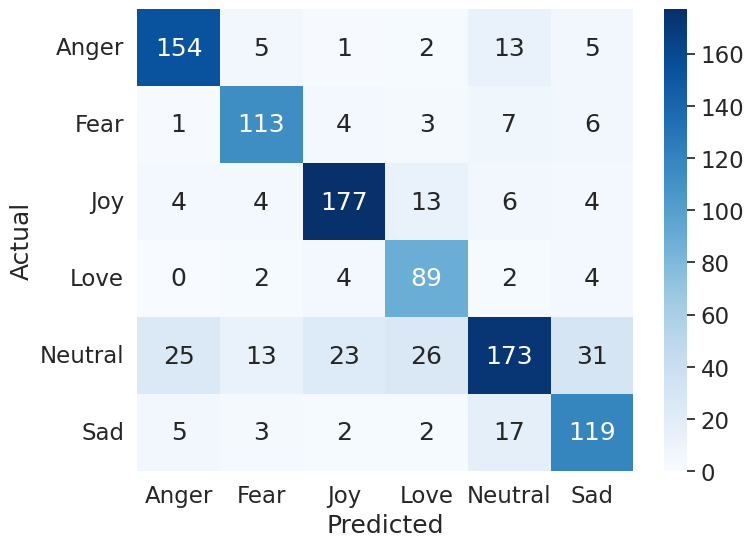

Training finished!


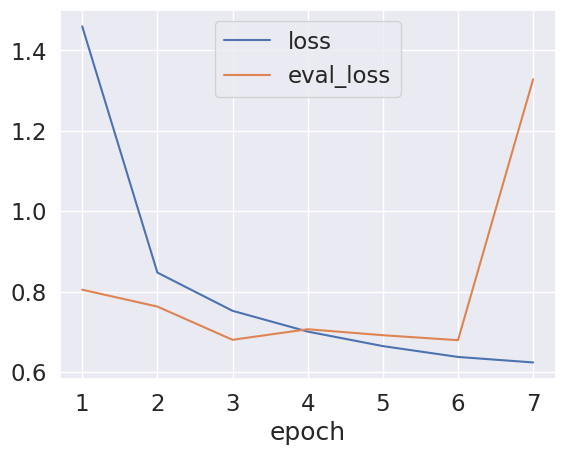

Total time: 13.56051637729009 minutes


In [12]:
#2 FacebookAI/xlm-roberta-large peft

main(
    model_name = 'FacebookAI/xlm-roberta-large',
    output_dir = 'p-emotcls-xlm-r-large',
    best_params = 'best_params/p-xlm-r-large.json'
)

In [13]:
%cd content/

[Errno 2] No such file or directory: 'content/'
/content/ft_XLM_RoBERTa_Large


In [14]:
!zip -r ft_XLM_RoBERTa_Large.zip /content/ft_XLM_RoBERTa_Large/

  adding: content/ft_XLM_RoBERTa_Large/ (stored 0%)
  adding: content/ft_XLM_RoBERTa_Large/bert_fine_tuning_peft.py (deflated 65%)
  adding: content/ft_XLM_RoBERTa_Large/run_hp_tuning_peft.sh (deflated 72%)
  adding: content/ft_XLM_RoBERTa_Large/best_params/ (stored 0%)
  adding: content/ft_XLM_RoBERTa_Large/best_params/p-xlm-r-large.json (deflated 25%)
  adding: content/ft_XLM_RoBERTa_Large/best_params/runs/ (stored 0%)
  adding: content/ft_XLM_RoBERTa_Large/best_params/runs/Jul20_05-07-24_4593452d387d/ (stored 0%)
  adding: content/ft_XLM_RoBERTa_Large/best_params/runs/Jul20_05-07-24_4593452d387d/events.out.tfevents.1784524044.4593452d387d.44064.5 (deflated 60%)
  adding: content/ft_XLM_RoBERTa_Large/best_params/runs/Oct01_02-49-23_b17de824b2a9/ (stored 0%)
  adding: content/ft_XLM_RoBERTa_Large/best_params/runs/Oct01_02-49-23_b17de824b2a9/events.out.tfevents.1790822965.b17de824b2a9.22367.0 (deflated 62%)
  adding: content/ft_XLM_RoBERTa_Large/best_params/runs/Oct01_02-46-30_b17de824

In [15]:
from google.colab import files
files.download('ft_XLM_RoBERTa_Large.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>